# Módulo 1 na prática: para que serve cada ferramenta

**Curso NeuroFluidos, Fundamentos de Aprendizado de Máquina Científico para Mecânica dos Fluidos**
Prof. Dr. Rodrigo Figueiredo Abdo

Este notebook aplica cada ferramenta do Módulo 1 a um escoamento **real**: a esteira de vórtices atrás de um cilindro a $Re=100$, o exemplo clássico de POD em mecânica dos fluidos. Os dados são 151 campos de vorticidade de uma simulação. A cada seção, uma ferramenta é aplicada a esses dados, com o "para que serve" no início.

> **Como usar:** rode as células de cima para baixo (no Colab, `Shift+Enter`). Precisa de `numpy`, `matplotlib` e `scipy`, todos já no Colab. A primeira célula baixa os dados (~100 MB, uma vez).

**Roteiro (os mesmos dados, nove ferramentas):**

| # | Ferramenta | Para que serve, em uma linha |
|---|---|---|
| 1 | Matriz de dados | Organizar os snapshots em colunas |
| 2 | Posto e espaço coluna | Descobrir quantas direções reais existem nos dados |
| 3 | Normas | Medir tamanho e erro de aproximação |
| 4 | SVD | Encontrar as direções dominantes dos dados |
| 5 | SVD truncada (Eckart-Young) | Comprimir guardando poucas direções |
| 6 | PCA | Reduzir dimensão preservando a variância |
| 7 | POD | Extrair os modos coerentes de energia do escoamento |
| 8 | Representação reduzida | Descrever o estado com poucas coordenadas |
| 9 | ROM linear | Modelar a dinâmica das coordenadas e prever |

## O fenômeno: uma esteira de von Kármán

Antes dos dados, o fenômeno real. A imagem abaixo é um experimento de laboratório: vapor de óleo escoando em torno de um cilindro, que torna visíveis os vórtices alternados que se desprendem e avançam rio abaixo. Os dados que vamos analisar são uma simulação numérica do mesmo fenômeno, a esteira de von Kármán atrás de um cilindro.

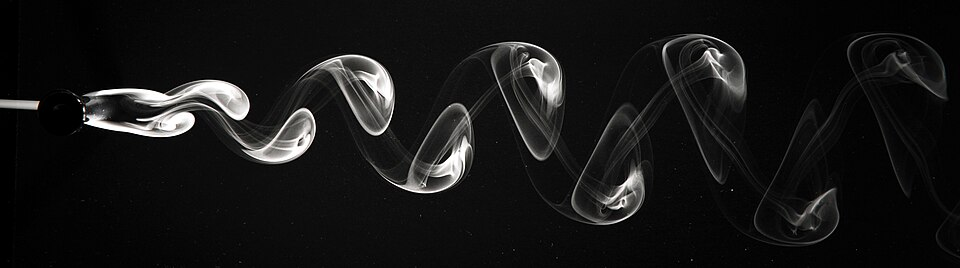

*Experimento: Jürgen Wagner (Wikimedia Commons), CC-BY-SA 4.0.*

## 0. Os dados: a esteira de um cilindro

Vamos usar um conjunto de dados clássico de POD em escoamentos: o escoamento 2D ao redor de um cilindro a $Re=100$, do livro *Data-Driven Science and Engineering* (Brunton e Kutz). São 151 campos de **vorticidade** numa malha de $449\times 199$ pontos, igualmente espaçados no tempo, cobrindo cerca de cinco ciclos de desprendimento de vórtices.

A célula abaixo baixa o arquivo (`VORTALL.mat`, ~100 MB) e o carrega. Cada coluna é um snapshot; cada snapshot é um campo de vorticidade achatado.

In [2]:
import os, urllib.request
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import pandas as pd

# --- ajustes de figura ---
plt.rcParams['image.cmap'] = 'RdBu_r'   # mapa divergente: azul negativo, vermelho positivo
plt.rcParams['axes.grid']  = False

# --- baixa o arquivo de dados, so na primeira vez ---
URL = "https://raw.githubusercontent.com/dynamicslab/databook_python/master/DATA/VORTALL.mat"
ARQ = "VORTALL.mat"
if not os.path.exists(ARQ):                      # se ainda nao existe, baixa
    print("baixando", ARQ, "(~100 MB, so na primeira vez)...")
    urllib.request.urlretrieve(URL, ARQ)

# --- carrega os snapshots numa matriz X ---
X  = sio.loadmat(ARQ)["VORTALL"].astype(float)   # (89351 pontos) x (151 snapshots)
nx, ny = 449, 199                                # malha: 449 no sentido do escoamento, 199 transversal

def campo(coluna):
    "Remonta uma coluna (campo achatado) na imagem 2D (ny, nx) para visualizar."
    return coluna.reshape(nx, ny).T              # (nx*ny,) -> (nx, ny) -> transpoe -> (ny, nx)

print("dados carregados:", X.shape, "-> n =", X.shape[0], "pontos,  m =", X.shape[1], "snapshots")

dados carregados: (89351, 151) -> n = 89351 pontos,  m = 151 snapshots


Vamos ver três instantes. O cilindro está à esquerda (o disco branco), e a esteira de vórtices alternados, azul e vermelho, se desprende e avança para a direita. É a esteira de von Kármán.

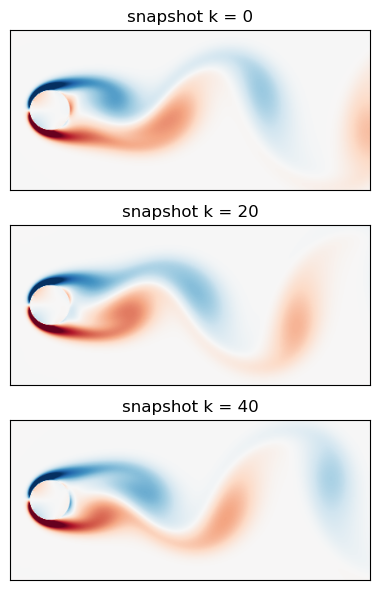

In [84]:
# mostra 3 instantes do escoamento (colunas 0, 20 e 40 da matriz X)
fig, axes = plt.subplots(3, 1, figsize=(9, 6))
for ax, k in zip(axes, [0, 20, 40]):
    ax.imshow(campo(X[:, k]), origin='lower', vmin=-5, vmax=5, aspect='equal')  # clip em +-5 p/ contraste
    ax.set_title(f"snapshot k = {k}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Compare estes snapshots com o experimento de laboratório mostrado no início: é o mesmo tipo de escoamento, aqui numa simulação numérica. O mesmo padrão aparece em escala planetária, nas nuvens atrás de ilhas, visto de satélite ([NASA](https://science.nasa.gov/earth/earth-observatory/a-vortex-street-in-the-arctic-2270), domínio público).

A partir daqui, todas as ferramentas operam sobre estes dados.

## 1. Matriz de dados: os snapshots em colunas

> **Para que serve:** pôr os dados num formato que a álgebra linear processa. Todas as ferramentas seguintes operam sobre esta matriz.

Convenção do curso (POD): **cada snapshot é uma coluna**. O campo de cada instante ($n = n_x n_y$ pontos) vira um vetor coluna, e os $m$ instantes ficam lado a lado:
$$ X = \big[\; \omega(t_1)\;\big|\;\omega(t_2)\;\big|\;\cdots\;\big|\;\omega(t_m)\;\big], \qquad X \in \mathbb{R}^{n\times m}. $$
As linhas são pontos do espaço; as colunas, instantes de tempo. Aqui $\omega$ é a vorticidade.

In [3]:
n, m = X.shape                                   # n = pontos no espaco, m = snapshots no tempo
print("n =", n, "pontos no espaco (linhas)")
print("m =", m, "snapshots no tempo (colunas)")

df = pd.DataFrame(X)
df

n = 89351 pontos no espaco (linhas)
m = 151 snapshots no tempo (colunas)


,0,1,2,3,4,5,6,7,8,9,...,141,142,143,144,145,146,147,148,149,150
0,-5.922200e-15,-4.683180e-15,-2.949020e-15,-1.084500e-15,-8.556910e-16,-2.708320e-16,8.393970e-16,8.867920e-16,7.422430e-16,-5.260060e-16,...,-9.900840e-15,-9.897190e-15,-1.052920e-14,-1.091700e-14,-1.137240e-14,-1.135940e-14,-1.015810e-14,-9.620250e-15,-8.864210e-15,-7.278530e-15
1,-6.016240e-15,-4.612050e-15,-2.582380e-15,-1.045210e-15,-6.466520e-16,-2.923320e-16,1.057250e-15,9.142350e-16,8.284000e-16,-2.848640e-16,...,-1.010230e-14,-1.007960e-14,-1.073340e-14,-1.090800e-14,-1.167860e-14,-1.140350e-14,-1.036510e-14,-9.578910e-15,-8.895500e-15,-7.314060e-15
2,-5.921160e-15,-4.684130e-15,-2.509560e-15,-9.732560e-16,-5.265420e-16,7.900950e-18,1.185800e-15,8.602440e-16,9.597450e-16,-1.599600e-16,...,-1.025060e-14,-1.024850e-14,-1.083370e-14,-1.107220e-14,-1.177840e-14,-1.152800e-14,-1.064760e-14,-9.983900e-15,-8.954300e-15,-7.506860e-15
3,-5.873530e-15,-4.489820e-15,-2.586680e-15,-8.664220e-16,-3.332510e-16,2.983670e-16,1.561710e-15,8.045730e-16,9.956020e-16,1.342920e-16,...,-1.034070e-14,-1.053690e-14,-1.112950e-14,-1.115570e-14,-1.197020e-14,-1.147530e-14,-1.092670e-14,-1.027550e-14,-9.022650e-15,-7.678870e-15
4,-6.005040e-15,-4.462480e-15,-2.623280e-15,-7.371450e-16,-2.333680e-16,3.585740e-17,1.507040e-15,1.040770e-15,1.101320e-15,2.386620e-16,...,-1.059860e-14,-1.075980e-14,-1.133060e-14,-1.144290e-14,-1.206510e-14,-1.183940e-14,-1.125810e-14,-1.064800e-14,-9.052210e-15,-7.811970e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89346,-1.665940e-02,-7.235130e-03,-2.204980e-03,-4.643760e-04,-6.637710e-05,-6.350170e-06,-5.180630e-07,-5.242220e-07,-2.603430e-06,-1.547680e-05,...,-1.667380e-01,-8.394880e-02,-3.026290e-02,1.041770e-04,1.201120e-02,8.735710e-03,-5.160130e-03,-2.152820e-02,-3.079960e-02,-2.840160e-02
89347,-1.573660e-02,-6.565280e-03,-1.937620e-03,-3.970660e-04,-5.537810e-05,-5.179370e-06,-4.215460e-07,-4.483840e-07,-2.222020e-06,-1.315880e-05,...,-1.800500e-01,-9.825170e-02,-4.460780e-02,-1.427450e-02,-2.344950e-03,-4.868390e-03,-1.652070e-02,-2.908120e-02,-3.409280e-02,-2.863390e-02
89348,-1.473860e-02,-5.923270e-03,-1.695100e-03,-3.380850e-04,-4.597170e-05,-4.195970e-06,-3.410020e-07,-3.835180e-07,-1.896900e-06,-1.118900e-05,...,-1.930430e-01,-1.127280e-01,-5.927530e-02,-2.884760e-02,-1.654540e-02,-1.784040e-02,-2.683550e-02,-3.546960e-02,-3.648240e-02,-2.841280e-02
89349,-1.369560e-02,-5.311690e-03,-1.474720e-03,-2.861130e-04,-3.786790e-05,-3.363560e-06,-2.733770e-07,-3.280070e-07,-1.620080e-06,-9.519990e-06,...,-2.054520e-01,-1.271370e-01,-7.403750e-02,-4.339670e-02,-3.040090e-02,-3.006030e-02,-3.609040e-02,-4.077800e-02,-3.809100e-02,-2.782940e-02


## 2. Posto e espaço coluna: quantas direções reais existem?

> **Para que serve:** medir a dimensão verdadeira dos dados. Se as colunas são combinações de poucas direções, o escoamento mora num subespaço pequeno, e é isso que torna redução de ordem possível.

O **espaço coluna** de $X$ são todas as combinações lineares das colunas. O **posto** é a dimensão desse espaço. O posto numérico vem no máximo ($m = 151$), mas o que importa é o **posto efetivo**: quantas direções carregam energia. A SVD, adiante, mede isso, e para este escoamento o número é pequeno.

In [4]:
# posto numerico: numero de direcoes linearmente independentes que X realmente tem
print("posto numerico de X:", np.linalg.matrix_rank(X), " (de no maximo", min(X.shape), ")")
print("Numericamente cheio. Mas a esteira e periodica e de baixa dimensao:")
print("veremos que ~7 direcoes ja carregam 99% da energia.")

posto numerico de X: 151  (de no maximo 151 )
Numericamente cheio. Mas a esteira e periodica e de baixa dimensao:
veremos que ~7 direcoes ja carregam 99% da energia.


## 3. Normas: medir tamanho e erro

> **Para que serve:** transformar "essa aproximação é boa" numa conta. Sem uma norma não dá para dizer o quanto um modelo reduzido erra.

Duas normas de matriz aparecem o tempo todo:

- **Frobenius** $\|X\|_F=\sqrt{\sum_{ij}X_{ij}^2}$: a energia total.
- **Espectral** $\|X\|_2=\sigma_1$: o maior fator de amplificação, igual ao maior valor singular.

O uso principal é medir a **diferença** $\|X-\widehat X\|$ entre o dado e uma aproximação. É assim que julgamos quantos modos bastam.

In [5]:
frob = np.linalg.norm(X, 'fro')       # norma de Frobenius: energia total (raiz da soma dos quadrados)
spec = np.linalg.norm(X, 2)           # norma espectral: maior valor singular de X
print(f"||X||_F (energia total)              = {frob:.1f}")
print(f"||X||_2 (= maior valor singular)     = {spec:.1f}")

||X||_F (energia total)              = 4106.4
||X||_2 (= maior valor singular)     = 3575.8


## 4. SVD: as direções dominantes dos dados

> **Para que serve:** decompor qualquer matriz $X$ em três partes com significado, direções no espaço, importâncias e comportamento no tempo.

$$ X = U\,\Sigma\,V^{\top} = \sum_{j} \sigma_j\, u_j\, v_j^{\top}. $$

- $U$: colunas $u_j$ são **padrões espaciais**, ortonormais.
- $\Sigma$: valores singulares $\sigma_1\ge\sigma_2\ge\cdots$, a **importância** de cada padrão.
- $V^{\top}$: linhas $v_j^{\top}$ dão o **comportamento no tempo** de cada padrão.

Aplicando ao $X$ cru (com a média incluída), o espectro dos $\sigma_j$ tem uma característica marcante. Fora o primeiro (a média), os valores singulares vêm **em pares**: cada frequência do desprendimento aparece como um par de modos em quadratura (as amplitudes temporais são seno e cosseno), com valores singulares quase iguais.

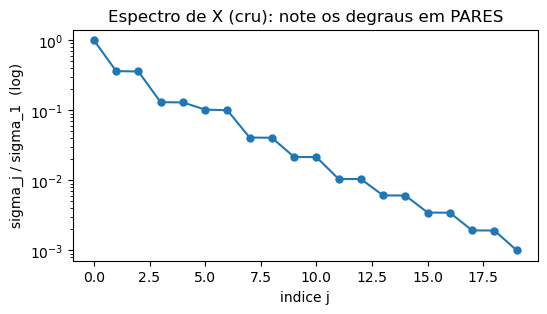

(89351, 151)
(151,)
(151, 151)


In [18]:
# SVD economica de X: X = Ur @ diag(sr) @ Vtr
#   Ur  -> padroes espaciais (colunas)
#   sr  -> valores singulares (importancias)
#   Vtr -> comportamento no tempo (linhas)
Ur, sr, Vtr = np.linalg.svd(X, full_matrices=False) # Guarda somente os primeiros k=min(n, m) vetores singulares -> (n, m) = (89351, 151); Ficando da seguinte forma: Ur (nxk), sr (k,k), Vtr (kxm)

# espectro dos valores singulares, normalizado por sigma_1, em escala log
plt.figure(figsize=(6, 3))
plt.semilogy(sr[:20] / sr[0], 'o-', ms=5)
plt.xlabel("indice j"); plt.ylabel("sigma_j / sigma_1  (log)")
plt.title("Espectro de X (cru): note os degraus em PARES")
plt.show()

print(Ur.shape)
print(sr.shape)
print(Vtr.shape)

Como não removemos a média, a primeira direção $u_1$ aproxima o escoamento médio (o campo médio, comum a todos os snapshots).

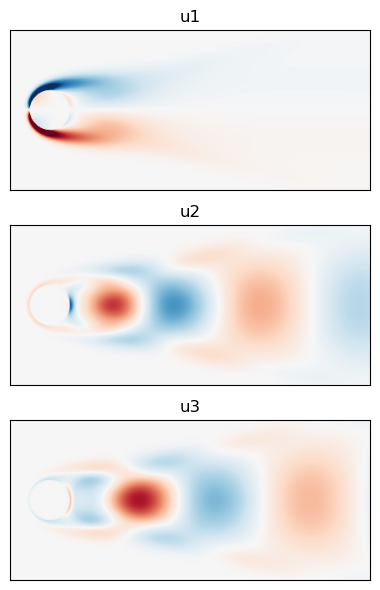

In [8]:
# os 3 primeiros padroes espaciais (colunas de Ur), remontados como campos
fig, axes = plt.subplots(3, 1, figsize=(9, 6))
titulos = ["u1", "u2", "u3"]
for ax, j, tit in zip(axes, [0, 1, 2], titulos):
    ax.imshow(campo(Ur[:, j]), origin='lower', cmap='RdBu_r', vmin=-0.02, vmax=0.02, aspect='equal')
    ax.set_title(tit); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 5. SVD truncada (Eckart-Young): comprimir com poucas direções

> **Para que serve:** guardar quase tudo com pouquíssimas direções. Cortar a SVD nos $r$ maiores termos dá a **melhor** aproximação de posto $r$ que existe (teorema de Eckart-Young). Como o sinal se concentra em poucas direções, poucas bastam. Em dados experimentais ruidosos, descartar as direções pequenas também atenua o ruído, que se espalha por elas.

A aproximação de posto $r$ é $X_r=\sum_{j=1}^{r}\sigma_j u_j v_j^{\top}$, e o erro em Frobenius é exatamente $\|X-X_r\|_F=\sqrt{\sum_{j>r}\sigma_j^2}$. Vamos **verificar essa igualdade** e ver o erro cair.

 r |  erro real  |  sqrt(soma sigma^2 restantes)  |  erro relativo
 1 |    2018.94 |      2018.94          |   49.17%
 2 |    1546.24 |      1546.24          |   37.65%
 4 |     731.78 |       731.78          |   17.82%
 6 |     431.97 |       431.97          |   10.52%
 8 |     192.62 |       192.62          |    4.69%
10 |     100.48 |       100.48          |    2.45%
15 |      20.94 |        20.94          |    0.51%
20 |       4.78 |         4.78          |    0.12%


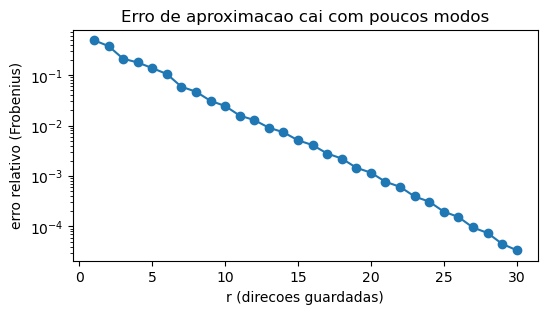

In [90]:
def aprox_posto(r):
    "Melhor aproximacao de posto r de X: guarda so os r maiores termos da SVD."
    return Ur[:, :r] @ np.diag(sr[:r]) @ Vtr[:r, :]

# compara o erro medido com a previsao do teorema de Eckart-Young
rs = [1, 2, 4, 6, 8, 10, 15, 20]
print(" r |  erro real  |  sqrt(soma sigma^2 restantes)  |  erro relativo")
for r in rs:
    real = np.linalg.norm(X - aprox_posto(r), 'fro')     # erro que de fato acontece
    teo  = np.sqrt(np.sum(sr[r:]**2))                    # previsao teorica (Eckart-Young)
    print(f"{r:2d} | {real:10.2f} | {teo:12.2f}          | {real/frob:8.2%}")

# curva do erro relativo em funcao de r (quantas direcoes guardamos)
plt.figure(figsize=(6, 3))
rr = np.arange(1, 31)
plt.semilogy(rr, [np.linalg.norm(X - aprox_posto(r), 'fro')/frob for r in rr], 'o-')
plt.xlabel("r (direcoes guardadas)"); plt.ylabel("erro relativo (Frobenius)")
plt.title("Erro de aproximacao cai com poucos modos"); plt.show()

As duas colunas coincidem: a igualdade de Eckart-Young, conferida numericamente. E poucas dezenas de modos, de 151, já reconstroem o escoamento com erro baixo. Comparação de um snapshot com sua reconstrução:

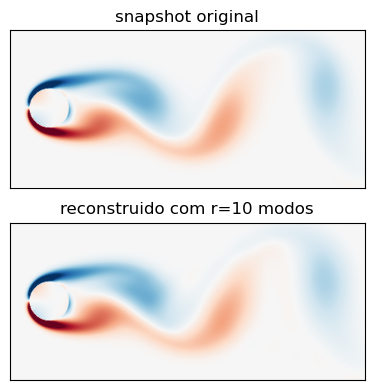

guardar r=10 termos comprime cerca de 15 vezes.


In [91]:
r = 10                                # numero de modos guardados
Xr = aprox_posto(r)                   # reconstrucao de posto r
k = 40                                # snapshot escolhido para comparar
fig, axes = plt.subplots(2, 1, figsize=(9, 4))
for ax, dado, tit in zip(axes, [X[:, k], Xr[:, k]],
                         ["snapshot original", f"reconstruido com r={r} modos"]):
    ax.imshow(campo(dado), origin='lower', vmin=-5, vmax=5, aspect='equal')
    ax.set_title(tit); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

# razao de compressao: tamanho de X contra o que a aproximacao de posto r guarda
comp = X.size / (Ur[:, :r].size + r + Vtr[:r, :].size)
print(f"guardar r={r} termos comprime cerca de {comp:.0f} vezes.")

## 6. PCA: reduzir dimensão preservando a variância

> **Para que serve:** encontrar as poucas combinações que concentram a maior parte da variação dos dados. A receita: **centrar** (tirar a média) e aplicar a SVD.

O PCA remove a média antes de aplicar a SVD. As direções dominantes passam a ser as estruturas da flutuação, e a importância de cada uma é o autovalor $\sigma_j^2$ (a energia; a variância é $\sigma_j^2/(m-1)$). Como reportamos a **fração** da energia, o fator $(m-1)$ se cancela.

In [22]:
xbar = X.mean(axis=1, keepdims=True)   # campo medio: media no tempo, ponto a ponto do espaco
Xc   = X - xbar                        # dados centrados = a flutuacao em torno da media
Uc, s, Vt = np.linalg.svd(Xc, full_matrices=False)   # PCA = SVD dos dados centrados
energia = s**2 / np.sum(s**2)          # fracao de energia (variancia) de cada componente

print("energia por componente (%), primeiras 8:")
print(np.round(energia[:8]*100, 2))
print("acumulada (%):", np.round(np.cumsum(energia[:8])*100, 2))
print(f"\nas duas primeiras (o par fundamental) ja somam {np.cumsum(energia)[1]:.1%};")
print(f"seis componentes somam {np.cumsum(energia)[5]:.1%} da energia.")

energia por componente (%), primeiras 8:
[41.34 40.17  5.35  5.28  3.28  3.14  0.52  0.52]
acumulada (%): [41.34 81.51 86.86 92.14 95.42 98.57 99.09 99.61]

as duas primeiras (o par fundamental) ja somam 81.5%;
seis componentes somam 98.6% da energia.


Uma nota de convenção. Aqui os dados estão com **espaço nas linhas e tempo nas colunas** (convenção de POD), então as direções espaciais saem em $U$. Na convenção comum de PCA em estatística, com **amostras nas linhas e variáveis nas colunas**, os dados estão transpostos, e as componentes principais aparecem em $V$. É a mesma conta; quem troca de lugar é o rótulo $U\leftrightarrow V$, porque a matriz foi transposta.

## 7. POD: os modos coerentes de energia do escoamento

> **Para que serve:** extrair as estruturas coerentes (os vórtices) ordenadas por energia, e descrever cada snapshot com poucos números. Para dados de escoamento, POD é o PCA da flutuação: os modos são os $\boldsymbol{\phi}_j$ (as colunas de $\Phi$), ordenados pela energia $\sigma_j^2$.

$$ \boldsymbol{u}(t_k) - \bar{\boldsymbol{u}} \;=\; \sum_j a_j(t_k)\, \boldsymbol{\phi}_j, \qquad a_j(t_k)=\sigma_j\, V_{kj}, $$

onde $\boldsymbol{u}(t_k)$ é o campo (aqui a vorticidade) no instante $k$. Os $\boldsymbol{\phi}_j$ são os **modos** (colunas de $\Phi$) e os $a_j(t)$ as **coordenadas temporais**. As coordenadas são a projeção do campo nos modos, $\boldsymbol{a}=\Phi^\top(\boldsymbol{u}-\bar{\boldsymbol{u}})$, o que dá o mesmo que $\Sigma V^\top$. O primeiro par de modos tem energia quase igual (o par de desprendimento), e suas coordenadas $(a_1,a_2)$ percorrem um círculo, o ciclo periódico da esteira.

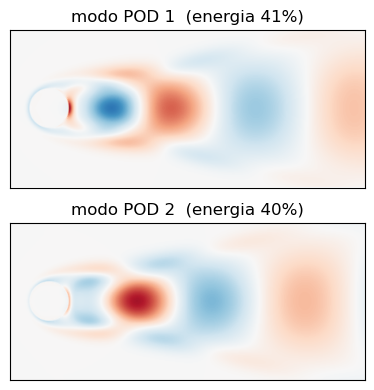

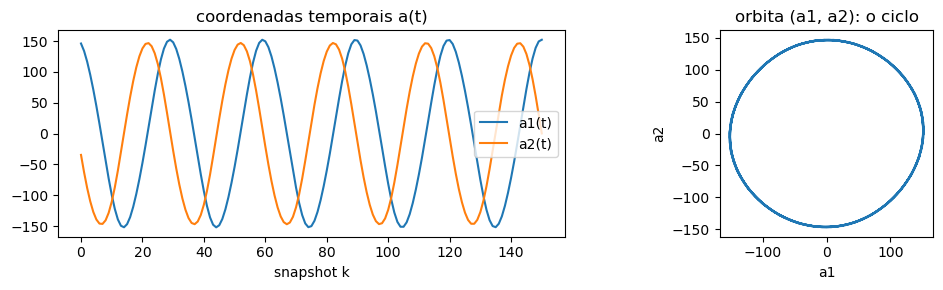

In [39]:
acoef = np.diag(s) @ Vt    # coordenadas a(t): coluna k = a(t_k), linha j = a_j(t). Equivale a Uc.T @ Xc (projecao nos modos)

# os 2 primeiros modos POD (colunas de Uc = Phi), como campos de vorticidade
fig, axes = plt.subplots(2, 1, figsize=(9, 4))
for ax, j in zip(axes, [0, 1]):
    ax.imshow(campo(Uc[:, j]), origin='lower', cmap='RdBu_r', vmin=-0.02, vmax=0.02, aspect='equal')
    ax.set_title(f"modo POD {j+1}  (energia {energia[j]:.0%})"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

# coeficientes no tempo, e a orbita do par (a1, a2)
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(acoef[0], label='a1(t)'); axes[0].plot(acoef[1], label='a2(t)')
axes[0].set_xlabel("snapshot k"); axes[0].set_title("coordenadas temporais a(t)"); axes[0].legend()
axes[1].plot(acoef[0], acoef[1]); axes[1].set_aspect('equal')     # a1 contra a2 = o ciclo
axes[1].set_xlabel("a1"); axes[1].set_ylabel("a2"); axes[1].set_title("orbita (a1, a2): o ciclo")
plt.tight_layout(); plt.show()

Os dois primeiros modos são o par de desprendimento, e a órbita $(a_1,a_2)$ é o ciclo periódico da esteira.

Uma questão prática: dá para obter tudo isso **sem** formar a covariância espacial $X_c X_c^{\top}$, que aqui seria $89351\times 89351$ (mais de 60 GB, inviável). O **método dos snapshots** usa a matriz pequena $K = X_c^{\top}X_c$, de tamanho $m\times m$ ($151\times 151$): seus autovalores são os $\sigma_j^2$ e seus autovetores dão os coeficientes temporais. Aqui isso não é conveniência, é necessidade. E repare no que $K$ é: uma **matriz simétrica**. É neste ponto, sobre os dados, que os autovalores e autovetores do módulo aparecem, e os autovalores de $K$ são exatamente as energias dos modos.

In [40]:
# metodo dos snapshots: em vez de Xc @ Xc.T (89351 x 89351), forma-se a matriz pequena K
K = Xc.T @ Xc                                 # K = Xc^T Xc, simetrica, apenas 151 x 151
lamK = np.sort(np.linalg.eigvalsh(K))[::-1]   # autovalores de K, do maior para o menor
print("sqrt dos autovalores de K :", np.round(np.sqrt(np.maximum(lamK[:5], 0)), 1))
print("valores singulares sigma_j :", np.round(s[:5], 1))
print("coincidem?", np.allclose(np.sqrt(np.maximum(lamK[:6], 0)), s[:6], rtol=1e-4))

sqrt dos autovalores de K : [1298.2 1279.6  466.8  463.9  365.8]
valores singulares sigma_j : [1298.2 1279.6  466.8  463.9  365.8]
coincidem? True


## 8. Representação reduzida do estado

> **Para que serve:** descrever cada instante do escoamento por um punhado de coordenadas $a_j(t)$, em vez de $n$ pontos. Esta é a representação reduzida do estado, $\boldsymbol{u}\approx\Phi\boldsymbol{a}$, o ponto de partida de um ROM.

Com $r$ modos, cada instante é $\widehat{\boldsymbol{u}}(t)=\bar{\boldsymbol{u}}+\Phi\,\boldsymbol{a}(t)=\bar{\boldsymbol{u}}+\sum_{j=1}^{r}a_j(t)\,\boldsymbol{\phi}_j$: um campo de $89351$ números vira $r$ coordenadas. Uma ressalva importante, e é a distinção central: aqui as coordenadas $\boldsymbol{a}(t)$ são **lidas dos dados**. Isto ainda **não** é um ROM, é a mesma reconstrução que o POD já faz, agora vista como "o estado em $r$ coordenadas".

reconstruindo com r=8 modos, erro relativo = 3.08%

campo cheio    :   13492001 numeros
media + 8 modos + 8 series :     805367 numeros
compressao: cerca de 17 vezes.


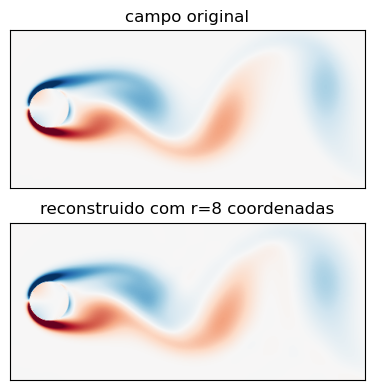

In [95]:
r = 8                                             # numero de coordenadas reduzidas
Xhat = xbar + Uc[:, :r] @ acoef[:r, :]            # reconstroi: media + soma dos r modos (u = media + Phi a)
print(f"reconstruindo com r={r} modos, erro relativo = {np.linalg.norm(X-Xhat,'fro')/frob:.2%}")

# quanto se guarda: campo cheio contra (media + r modos + r series temporais)
cheio    = X.size
reduzido = xbar.size + Uc[:, :r].size + acoef[:r, :].size
print(f"\ncampo cheio    : {cheio:>10d} numeros")
print(f"media + {r} modos + {r} series : {reduzido:>10d} numeros")
print(f"compressao: cerca de {cheio/reduzido:.0f} vezes.")

# original x reconstruido com so r coordenadas
k = 40
fig, axes = plt.subplots(2, 1, figsize=(9, 4))
for ax, dado, tit in zip(axes, [X[:, k], Xhat[:, k]],
                         ["campo original", f"reconstruido com r={r} coordenadas"]):
    ax.imshow(campo(dado), origin='lower', vmin=-5, vmax=5, aspect='equal')
    ax.set_title(tit); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

O **ROM** dá o passo que falta aqui: escreve uma equação para a **evolução** das coordenadas, o $\dot a_j$, e a **integra** para prever o escoamento sem a simulação completa.

É a distinção que o resumo enfatiza: **POD não é ROM**. A POD dá a base e o estado em poucas coordenadas, mas não a dinâmica. O ROM é a equação que faz essas coordenadas evoluírem. POD é a base; ROM é a dinâmica sobre a base.

## 9. ROM linear: a dinâmica das coordenadas

> **Para que serve:** modelar como as coordenadas $\boldsymbol{a}(t)$ evoluem no tempo. Em vez de ler $\boldsymbol{a}(t)$ dos dados, escrevemos uma equação para $\dot{\boldsymbol{a}}$ e a integramos para **prever** o escoamento, sem a simulação completa. É isto que faz de um modelo um ROM.

**Notação da aula.** O estado é $\boldsymbol{u}$ (aqui a vorticidade), os modos $\Phi=[\boldsymbol{\phi}_1\ \cdots\ \boldsymbol{\phi}_r]$ com $\Phi^\top\Phi=I_r$, e as coordenadas $\boldsymbol{a}=\Phi^\top\boldsymbol{u}$. A equação do escoamento é $\dot{\boldsymbol{u}}=\boldsymbol{F}(\boldsymbol{u})$; no **caso linear**, $\dot{\boldsymbol{u}}=A\,\boldsymbol{u}$. O ROM linear é uma equação fechada nas coordenadas, $\dot{\boldsymbol{a}}=A_r\,\boldsymbol{a}$, com $A_r\in\mathbb{R}^{r\times r}$.

**Como obter $A_r$? Dois caminhos.**

- **Caminho 1, Galerkin (a partir da física).** Substituir $\boldsymbol{u}\approx\Phi\boldsymbol{a}$ em $\dot{\boldsymbol{u}}=A\boldsymbol{u}$ e projetar nos modos ($\Phi^\top$) dá $A_r=\Phi^\top A\,\Phi$, a "sombra de $A$" no subespaço. Isto **precisa do operador $A$**, que vem das equações discretizadas (o Laplaciano da difusão, a advecção, os contornos), não dos dados.
- **Caminho 2, mínimos quadrados (a partir dos dados).** Quando **não temos $A$** (é o nosso caso, só snapshots), ajustamos $A_r$ direto aos dados. Temos a trajetória $\boldsymbol{a}(t)$ (da POD) e medimos sua taxa $\dot{\boldsymbol{a}}(t)$; procuramos a matriz que melhor satisfaz $\dot{\boldsymbol{a}}\approx A_r\boldsymbol{a}$. É este que vamos usar.

O ajuste do Caminho 2 é a regressão $\min_{A_r}\sum_k\lVert\dot{\boldsymbol{a}}_k-A_r\boldsymbol{a}_k\rVert^2$, cuja solução (equações normais) é
$$A_r=\Big(\sum_k\dot{\boldsymbol{a}}_k\,\boldsymbol{a}_k^\top\Big)\Big(\sum_k\boldsymbol{a}_k\,\boldsymbol{a}_k^\top\Big)^{-1}.$$
Fazemos isso no par dominante e integramos $\dot{\boldsymbol{a}}=A_r\boldsymbol{a}$ a partir de $\boldsymbol{a}(0)$.

In [53]:
from scipy.linalg import expm
from scipy.integrate import solve_ivp

# --- 1. coordenadas do par dominante e sua taxa de variacao no tempo (a-ponto) ---
apar = acoef[:2]                         # a(t) = (a1, a2) do par de desprendimento
adot = np.gradient(apar, axis=1)         # a-ponto por diferencas finitas (tempo = indice do snapshot)

# --- 2. ajusta o operador reduzido Ar tal que  a-ponto = Ar a  (minimos quadrados) ---
Ar = adot @ apar.T @ np.linalg.inv(apar @ apar.T)   # Ar = (sum a-ponto a^T)(sum a a^T)^-1
print("Ar ajustado (2x2):\n", np.round(Ar, 3))

# --- 3. INTEGRA a-ponto = Ar a a partir so de a(0), com integrador pronto ---
tk  = np.arange(apar.shape[1])           # instantes (em indice de snapshot)
sol = solve_ivp(lambda t, a: Ar @ a,     # a taxa:  a-ponto = Ar a
                (tk[0], tk[-1]),         # intervalo de tempo
                apar[:, 0],              # condicao inicial a(0)
                t_eval=tk)               # avaliar exatamente nos snapshots
apred = sol.y                            # trajetoria prevista, shape (2, m)
print(f"erro da previsao (so o modelo + a(0)) vs dado: {np.linalg.norm(apred-apar)/np.linalg.norm(apar):.1%}")

Ar ajustado (2x2):
 [[ 0.     0.21 ]
 [-0.203 -0.   ]]
erro da previsao (so o modelo + a(0)) vs dado: 11.5%


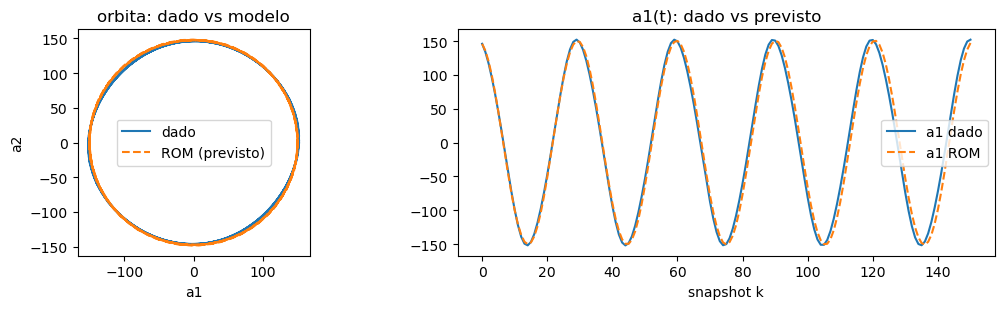

In [97]:
# compara a orbita e o coeficiente a1(t): dado vs previsto pelo modelo
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(apar[0], apar[1], label='dado')
axes[0].plot(apred[0], apred[1], '--', label='ROM (previsto)')
axes[0].set_aspect('equal'); axes[0].legend()
axes[0].set_xlabel("a1"); axes[0].set_ylabel("a2"); axes[0].set_title("orbita: dado vs modelo")
axes[1].plot(apar[0], label='a1 dado')
axes[1].plot(apred[0], '--', label='a1 ROM')
axes[1].set_xlabel("snapshot k"); axes[1].set_title("a1(t): dado vs previsto"); axes[1].legend()
plt.tight_layout(); plt.show()

O modelo linear reproduz o desprendimento fundamental: a órbita prevista é o mesmo círculo e recuperamos a frequência, tudo a partir de $\boldsymbol{a}(0)$ e da equação, sem os dados. Este $A_r$ foi **identificado dos dados**, não projetado de um $A$ físico (que não temos aqui).

Duas ressalvas honestas. Primeira: ajustamos $A_r$ e depois "prevemos" os **mesmos** snapshots, então isto é uma demonstração de **consistência** (um modelo linear consegue representar a trajetória), não uma previsão fora da amostra; um teste de verdade ajustaria $A_r$ nos primeiros ciclos e preveria os seguintes.

## Fecho: o mapa das ferramentas

Um mesmo escoamento real, nove ferramentas. O que cada uma respondeu:

| Ferramenta | A pergunta que ela responde | O que vimos nos dados |
|---|---|---|
| Matriz de dados | Como guardar o escoamento? | Snapshots viram colunas de $X$ |
| Posto / espaço coluna | Quantas direções reais há? | Numérico 151, efetivo $\approx 7$ |
| Normas | Quão boa é uma aproximação? | $\|X-\widehat X\|_F$ vira uma conta |
| SVD | Quais as direções dominantes? | $U\Sigma V^{\top}$, espectro em pares |
| SVD truncada | Como comprimir? | Eckart-Young conferido, ~15x (r=10) |
| PCA | Como reduzir preservando variância? | Centrar e aplicar SVD |
| POD | Quais os modos coerentes? | Par de desprendimento; autovalores de $K$ = energias |
| Representação reduzida | Como descrever o estado? | Campo $\to$ $r$ coordenadas $a_j(t)$ |
| ROM linear | Como prever a dinâmica? | $\dot{\boldsymbol{a}}=A_r\boldsymbol{a}$ ajustado e integrado |

O Módulo 1 é, no fundo, uma ideia: pôr os dados numa matriz e achar suas direções dominantes. A SVD é o motor; posto, normas, PCA e POD são leituras dela (a POD, por dentro, é um problema de autovalores); a representação reduzida e o ROM linear são o que se faz com o resultado. O Módulo 2 vai além, para a **dinâmica não linear** e outros métodos guiados por dados (regressão, DMD, SINDy, PINNs).

Para explorar: mude o número $r$ de modos guardados, veja o erro e a compressão; ou reconstrua um vídeo da esteira com poucos modos e compare com o original.